In [34]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

def consolidar_transferencias(url_diferidas, url_inmediatas):
    """
    Consolida transferencias diferidas e inmediatas en un único DataFrame.

    Parameters
    ----------
    url_diferidas : str
        Ruta del archivo TDS (Diferidas).
    url_inmediatas : str
        Ruta del archivo TIS (Inmediatas).

    Returns
    -------
    pd.DataFrame
        DataFrame consolidado.
    """

    # =========================
    # Lectura de archivos
    # =========================
    df_1 = pd.read_csv(url_diferidas, sep=';', encoding='latin-1')
    df_2 = pd.read_csv(url_inmediatas, sep=';', encoding='latin-1')

    df_1.columns = df_1.columns.str.strip()
    df_2.columns = df_2.columns.str.strip()

    # =========================
    # Formateo de horas
    # =========================
    df_1['HORA TRANSFERENCIA'] = (
        df_1['HORA TRANSFERENCIA']
        .astype(float)
        .astype(int)
        .astype(str)
        .str.zfill(6)
        .str.replace(r'(\d{2})(\d{2})(\d{2})',
                     r'\1:\2:\3',
                     regex=True)
    )

    df_2['HORA PROCESO'] = (
        df_2['HORA PROCESO']
        .astype(float)
        .astype(int)
        .astype(str)
        .str.zfill(6)
        .str.replace(r'(\d{2})(\d{2})(\d{2})',
                     r'\1:\2:\3',
                     regex=True)
    )

    # =========================
    # Mapeo de bancos
    # =========================
    mapeo_bancos = {
        'BCP BANCO DE CRÉDITO': 'BANCO DE CREDITO',
        'BCO.DE LA NACION': 'BANCO DE LA NACION',
        'BCO.DE COMERCIO': 'BANCOMER',
        'CAJA METROPOLITA': 'CAJA METROPOLITANA DE LIMA',
        'CMAC PIURA S.A.C': 'CAJA PIURA',
        'CONFIANZA': 'FINANCIERA CONFIANZA',
        'CITIBANK': 'CITIBANK DEL PERU S.A.',
        'COMPARTAMOS': 'COMPARTAMOS FINANCIERA',
        'EEDE': 'EEDE TARJETAS PERUANAS',
        'B.I.F.': 'BANBIF',
        'BCO. FALABELLA': 'BANCO FALABELLA',
        'ALFIN BANCO': 'ALFIN BANCO S.A.',
        'SIP / AGORA / OH': 'SIP / AGORA / OH!',
        'BCO.SANTANDER': 'BANCO SANTANDER PERU S.A.',
        'GNB': 'BANCO GNB',
        'CMAC CUSCO': 'CAJA CUSCO',
        'CMAC AREQUIPA': 'CAJA AREQUIPA',
        'CMAC TRUJILLO': 'CAJA TRUJILLO',
        'CMAC ICA': 'CAJA ICA',
        'FINANCIERA EFECT': 'FINANCIERA EFECTIVA',
        'CAJA LOS ANDES': 'LOS ANDES'
    }

    for df in [df_1, df_2]:
        df['NOMBRE ENTIDAD DESTINO'] = (
            df['NOMBRE ENTIDAD DESTINO']
            .astype(str)
            .str.strip()
            .map(mapeo_bancos)
            .fillna(df['NOMBRE ENTIDAD DESTINO'].astype(str).str.strip())
        )

    # =========================
    # Filtros
    # =========================
    df_2_new = df_2[
        (df_2['DESCRIPCION CANAL'] == 'APP MOVIL') &
        (df_2['DESCRIPCION CLASE CLIENTE'] == 'CLTE. NATURAL') &
        (df_2['MONEDA ABONO'] == 'PEN')
    ].copy()

    df_1_new = df_1[
        (df_1['DESCRIPCION TIPO'] == 'CLTE. NATURAL') &
        (df_1['CANAL'] == 'APP MOVIL') &
        (df_1['MONEDA CARGO'] == 'PEN')
    ].copy()

    df_1_new['INTEROP. QR'] = ''

    # =========================
    # Estandarización Inmediatas
    # =========================
    df_inm_clean = df_2_new[[
        'CODIGO CLIENTE',
        'DESCRIPCION CLASE CLIENTE',
        'MONEDA ABONO',
        'FECHA PROCESO',
        'HORA PROCESO',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'DESCRIPCION CANAL',
        'NOMBRE CLIENTE ORIGEN',
        'NOMBRE CLIENTE BENEFICIARIO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]].copy()

    df_inm_clean.columns = [
        'CODIGO CLIENTE',
        'TIPO CLIENTE',
        'MONEDA ABONO',
        'FECHA TRANSFERENCIA',
        'HORA TRANSFERENCIA',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'CANAL',
        'NOMBRE CLIENTE ORIGINANTE',
        'NOMBRE CLIENTE DESTINO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]

    df_inm_clean['Tipo'] = 'Inmediatas'

    # =========================
    # Estandarización Diferidas
    # =========================
    df_dif_clean = df_1_new[[
        'CODIGO CLIENTE',
        'DESCRIPCION TIPO',
        'MONEDA ABONO',
        'FECHA DE TRANSFERENCIA',
        'HORA TRANSFERENCIA',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'CANAL',
        'NOMBRE CLIENTE  ORIGINANTE',
        'NOMBRE CLIENTE DESTINO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]].copy()

    df_dif_clean.columns = [
        'CODIGO CLIENTE',
        'TIPO CLIENTE',
        'MONEDA ABONO',
        'FECHA TRANSFERENCIA',
        'HORA TRANSFERENCIA',
        'NOMBRE ENT ORIGEN',
        'NOMBRE ENTIDAD DESTINO',
        'CANAL',
        'NOMBRE CLIENTE ORIGINANTE',
        'NOMBRE CLIENTE DESTINO',
        'IMPORTE TRANSFERENCIA',
        'INTEROP. QR'
    ]

    df_dif_clean['Tipo'] = 'Diferidas'

    # =========================
    # Consolidación final
    # =========================
    df_consolidado = pd.concat(
        [df_inm_clean, df_dif_clean],
        ignore_index=True
    )

    df_consolidado['INTEROP. QR'] = df_consolidado['INTEROP. QR'].replace(r'^\s*$', np.nan, regex=True)
    df_consolidado['INTEROP. QR'] = df_consolidado['INTEROP. QR'].fillna('Otros')

    print(f"Total registros unificados: {len(df_consolidado)}")
    print(df_consolidado['Tipo'].value_counts())
    
    return df_consolidado


url_1 = r'D:\Users\SAUOCH\Downloads\TDS_20260709_111723_3_BFPCESVIE (1).csv'
url_2 = r'D:\Users\SAUOCH\Downloads\TIS_20260709_104046_1_BFPCESVIE (1).csv'

df_consolidado = consolidar_transferencias(url_1, url_2)

df_consolidado.head()

Total registros unificados: 721497
Tipo
Inmediatas    718588
Diferidas       2909
Name: count, dtype: int64


,CODIGO CLIENTE,TIPO CLIENTE,MONEDA ABONO,FECHA TRANSFERENCIA,HORA TRANSFERENCIA,NOMBRE ENT ORIGEN,NOMBRE ENTIDAD DESTINO,CANAL,NOMBRE CLIENTE ORIGINANTE,NOMBRE CLIENTE DESTINO,IMPORTE TRANSFERENCIA,INTEROP. QR,Tipo
0,3599440,CLTE. NATURAL,PEN,20260601,00:05:08,BANCO PICHINCHA,nan,APP MOVIL,JONATAN JOSUE ANCHANTE CLAUSEN,NaN,20.0,ENVIO CONTACTO,Inmediatas
1,3599440,CLTE. NATURAL,PEN,20260601,00:05:12,BANCO PICHINCHA,BANCO DE CREDITO,APP MOVIL,JONATAN JOSUE ANCHANTE CLAUSEN,JONATAN JOSUE ANCHANTE CLAUSEN,20.0,ENVIO CONTACTO,Inmediatas
2,577382,CLTE. NATURAL,PEN,20260601,00:05:32,BANCO PICHINCHA,nan,APP MOVIL,JOSE TAPIA SEDANO,NaN,30.0,ENVIO CONTACTO,Inmediatas
3,3986657,CLTE. NATURAL,PEN,20260601,00:05:35,BANCO PICHINCHA,BANCO DE CREDITO,APP MOVIL,EVELYN ROCIO JINES SARAVIA,EVELYN ROCIO JINES SARAVIA,20.0,Otros,Inmediatas
4,577382,CLTE. NATURAL,PEN,20260601,00:05:41,BANCO PICHINCHA,BANCO DE CREDITO,APP MOVIL,JOSE TAPIA SEDANO,JOSE GUSTAVO TAPIA SEDANO,30.0,ENVIO CONTACTO,Inmediatas


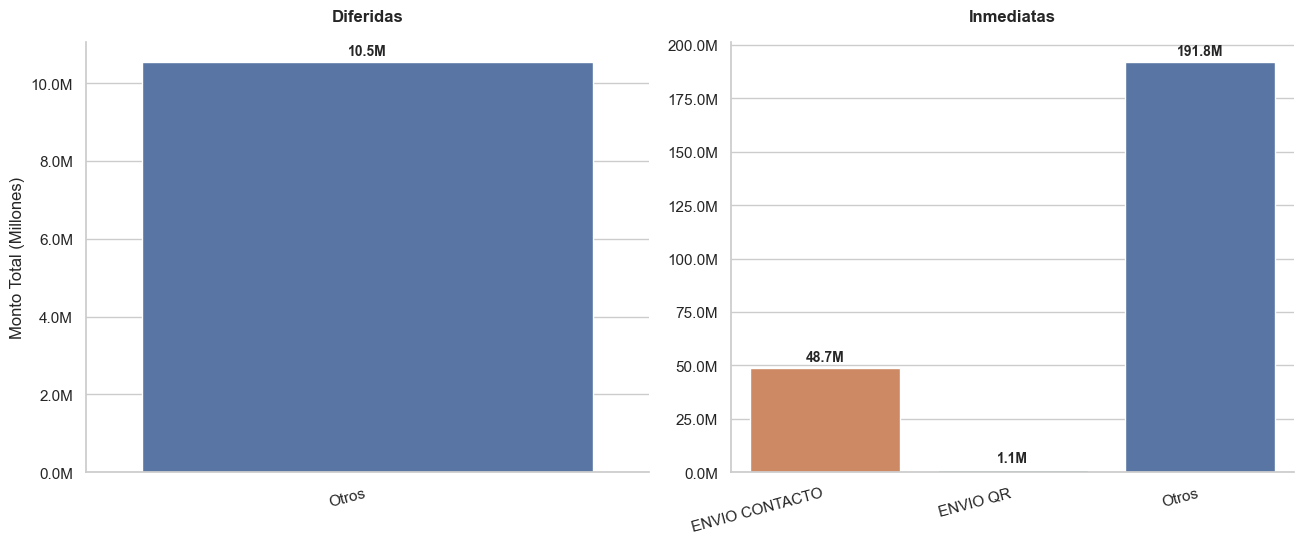

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar y calcular la suma en millones
df_grafico = df_consolidado.groupby(['Tipo', 'INTEROP. QR'], as_index=False)['IMPORTE TRANSFERENCIA'].sum()
df_grafico['IMPORTE_MILLONES'] = df_grafico['IMPORTE TRANSFERENCIA'] / 1_000_000

df_filtrado = df_grafico[df_grafico['Tipo'].isin(['Diferidas', 'Inmediatas'])]

# Ajustamos el estilo visual de Seaborn
sns.set_theme(style="whitegrid")

# 2. Crear gráficos separados con escalas Y independientes (sharey=False)
g = sns.catplot(
    data=df_filtrado,
    kind='bar',
    x='INTEROP. QR',     # Cambiamos X a 'INTEROP. QR' para mejor distribución
    y='IMPORTE_MILLONES',
    hue='INTEROP. QR',   # Mantiene los colores por categoría
    col='Tipo',          
    sharex=False,        
    sharey=False,        # <--- CLAVE: Escalas independientes para cada gráfico
    height=6,
    aspect=1.1,          # Un poco más ancho para que entren los textos
    legend=False         # Apagamos la leyenda externa por redundancia
)

# 3. Personalizar títulos y limpiar ejes
g.set_titles("{col_name}", fontsize=14, weight='bold', pad=15)
g.set_axis_labels("", "Monto Total (Millones)")

# 4. Formatear ejes Y y agregar etiquetas sobre las barras
for ax in g.axes.flat:
    # Formato de números con "M"
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.1f}M"))
    
    # Rotar ligeramente las etiquetas X para evitar colisiones si son largas
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
    
    # Agregar el valor numérico exacto arriba de cada barra
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.1fM', 
            padding=3, 
            fontsize=10, 
            weight='semibold'
        )

plt.tight_layout()
# Ajustar márgenes superiores para que no se corten las etiquetas de los números
plt.subplots_adjust(top=0.85) 
plt.show()


In [36]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. ESCENARIO A: CÁLCULO DE MÉTRICAS GLOBALES (SIN FILTROS)
# =====================================================================
total_op_global = len(df_consolidado)
monto_global_m = df_consolidado['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
clientes_global = df_consolidado['CODIGO CLIENTE'].nunique()

# Desglose Global por Canal (Tipo)
df_inm_glob = df_consolidado[df_consolidado['Tipo'] == 'Inmediatas']
monto_inm_glob_m = df_inm_glob['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
ticket_inm_glob = df_inm_glob['IMPORTE TRANSFERENCIA'].mean() if len(df_inm_glob) > 0 else 0

df_dif_glob = df_consolidado[df_consolidado['Tipo'] == 'Diferidas']
monto_dif_glob_m = df_dif_glob['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
ticket_dif_glob = df_dif_glob['IMPORTE TRANSFERENCIA'].mean() if len(df_dif_glob) > 0 else 0

# Desglose Global por Origen (INTEROP. QR) ordenado de mayor a menor
df_interop_monto = (df_consolidado.groupby('INTEROP. QR')['IMPORTE TRANSFERENCIA'].sum().sort_values(ascending=False) / 1_000_000)


# =====================================================================
# 2. ESCENARIO B: ZOOM DE ENFOQUE (SÓLO CATEGORÍA "OTROS")
# =====================================================================
# Filtramos la raíz del problema identificada por tu jefa
df_otros = df_consolidado[df_consolidado['INTEROP. QR'] == 'Otros']

total_op_otros = len(df_otros)
monto_otros_m = df_otros['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
clientes_otros = df_otros['CODIGO CLIENTE'].nunique()

# Desglose interno de "Otros" por Tipo de Canal
df_inm_otros = df_otros[df_otros['Tipo'] == 'Inmediatas']
tx_inm_otros = len(df_inm_otros)
monto_inm_otros_m = df_inm_otros['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
ticket_inm_otros = df_inm_otros['IMPORTE TRANSFERENCIA'].mean() if tx_inm_otros > 0 else 0

df_dif_otros = df_otros[df_otros['Tipo'] == 'Diferidas']
tx_dif_otros = len(df_dif_otros)
monto_dif_otros_m = df_dif_otros['IMPORTE TRANSFERENCIA'].sum() / 1_000_000
ticket_dif_otros = df_dif_otros['IMPORTE TRANSFERENCIA'].mean() if tx_dif_otros > 0 else 0

# Cálculo del porcentaje de participación de 'Otros' frente al total general
porcentaje_otros_global = (monto_otros_m / monto_global_m) * 100 if monto_global_m > 0 else 0


# =====================================================================
# 3. IMPRESIÓN DEL DASHBOARD ESTRATÉGICO DE NEGOCIO
# =====================================================================
print("=" * 85)
print(" 📊  DASHBOARD ESTRATÉGICO - HISTORIA DE EXPOSICIÓN Y FUGA (JUNIO)")
print("=" * 85)

# --- Bloque General ---
print(f" 🌐 1. PANORAMA GENERAL (Sin Filtros):")
print(f"    • Monto Total de Salida  : S/ {monto_global_m:,.2f} Millones de PEN")
print(f"    • Clientes Únicos Activos : {clientes_global:,} Usuarios")
print(f"    • Ticket Promedio CCE     : Inmediatas S/ {ticket_inm_glob:,.2f} | Diferidas S/ {ticket_dif_glob:,.2f}")
print(f"\n    🔍 PARTICIPACIÓN POR ORIGEN (INTEROP. QR):")

# Listado dinámico de la tajada de dinero que se lleva cada categoría de INTEROP. QR
for categoria, monto_cat in df_interop_monto.items():
    porcentaje_cat = (monto_cat / monto_global_m) * 100 if monto_global_m > 0 else 0
    indicador = "🚨" if categoria == "Otros" else "▪️"
    print(f"      {indicador} {categoria:<18}: S/ {monto_cat:,.2f}M ({porcentaje_cat:.1f}%)")

print("-" * 85)

# --- Bloque de Concentración ("Otros") ---
print(f" 🎯 2. ZOOM AL FOCO DE ALTO VALOR (Sólo Categoría 'Otros'):")
print(f"    • Monto Concentrado Aquí  : S/ {monto_otros_m:,.2f}M ({porcentaje_otros_global:.1f}% del total global)")
print(f"    • Clientes Involucrados   : {clientes_otros:,} Usuarios")
print(f"    • Operaciones Ejecutadas  : {total_op_otros:,} Transacciones")
print("-" * 85)

# --- Desglose Interno del Comportamiento Técnico ---
print(f"    ⚡ COMPORTAMIENTO DE LOS GRANDES MONTOS EN 'OTROS':")
print(f"    🟦 Transferencias Inmediatas:")
print(f"       • Monto Fugado     : S/ {monto_inm_otros_m:,.2f}M ({(monto_inm_otros_m / monto_otros_m)*100:.1f}%)")
print(f"       • Ticket Promedio  : S/ {ticket_inm_otros:,.2f} PEN")
print(f"    🟧 Transferencias Diferidas:")
print(f"       • Monto Fugado     : S/ {monto_dif_otros_m:,.2f}M ({(monto_dif_otros_m / monto_otros_m)*100:.1f}%)")
print(f"       • Ticket Promedio  : S/ {ticket_dif_otros:,.2f} PEN")
print("=" * 85)

# --- Discurso de Negocio Integrado para la Presentación ---
print("💡 Discurso para la Jefa (Apertura de la Mesa de Trabajo):")
print(f"\"Para iniciar la sesión, pongamos el problema en dimensión: Durante el mes de junio, la App experimentó")
print(f" una salida global de S/ {monto_global_m:,.2f}M. Sin embargo, nuestro análisis de riesgo detectó que")
print(f" el verdadero peligro no está distribuido equitativamente, sino concentrado críticamente en la categoría 'Otros',")
print(f" la cual absorbe por sí sola S/ {monto_otros_m:,.2f}M —es decir, el {porcentaje_otros_global:.1f}% de toda la fuga del banco—. \"\n")

print(f"\"Al abrir la caja de 'Otros', confirmamos la hipótesis de que aquí se orquestan los movimientos más agresivos:")
print(f" mientras que las transferencias inmediatas de este grupo mueven un ticket promedio de S/ {ticket_inm_otros:,.2f},")
print(f" las diferidas se disparan exponencialmente hasta alcanzar un ticket promedio de S/ {ticket_dif_otros:,.2f} por operación.")
print(f" Este comportamiento confirma un patrón de vaciado de cuentas de ahorros de alto valor mediante operaciones")
print(f" diferidas programadas, y sobre este segmento es donde ejecutaremos las medidas de contención.\"")
print("=" * 85)


 📊  DASHBOARD ESTRATÉGICO - HISTORIA DE EXPOSICIÓN Y FUGA (JUNIO)
 🌐 1. PANORAMA GENERAL (Sin Filtros):
    • Monto Total de Salida  : S/ 252.15 Millones de PEN
    • Clientes Únicos Activos : 59,108 Usuarios
    • Ticket Promedio CCE     : Inmediatas S/ 336.24 | Diferidas S/ 3,621.61

    🔍 PARTICIPACIÓN POR ORIGEN (INTEROP. QR):
      🚨 Otros             : S/ 202.35M (80.2%)
      ▪️ ENVIO CONTACTO    : S/ 48.67M (19.3%)
      ▪️ ENVIO QR          : S/ 1.13M (0.4%)
-------------------------------------------------------------------------------------
 🎯 2. ZOOM AL FOCO DE ALTO VALOR (Sólo Categoría 'Otros'):
    • Monto Concentrado Aquí  : S/ 202.35M (80.2% del total global)
    • Clientes Involucrados   : 34,208 Usuarios
    • Operaciones Ejecutadas  : 284,770 Transacciones
-------------------------------------------------------------------------------------
    ⚡ COMPORTAMIENTO DE LOS GRANDES MONTOS EN 'OTROS':
    🟦 Transferencias Inmediatas:
       • Monto Fugado     : S/ 191.82M 

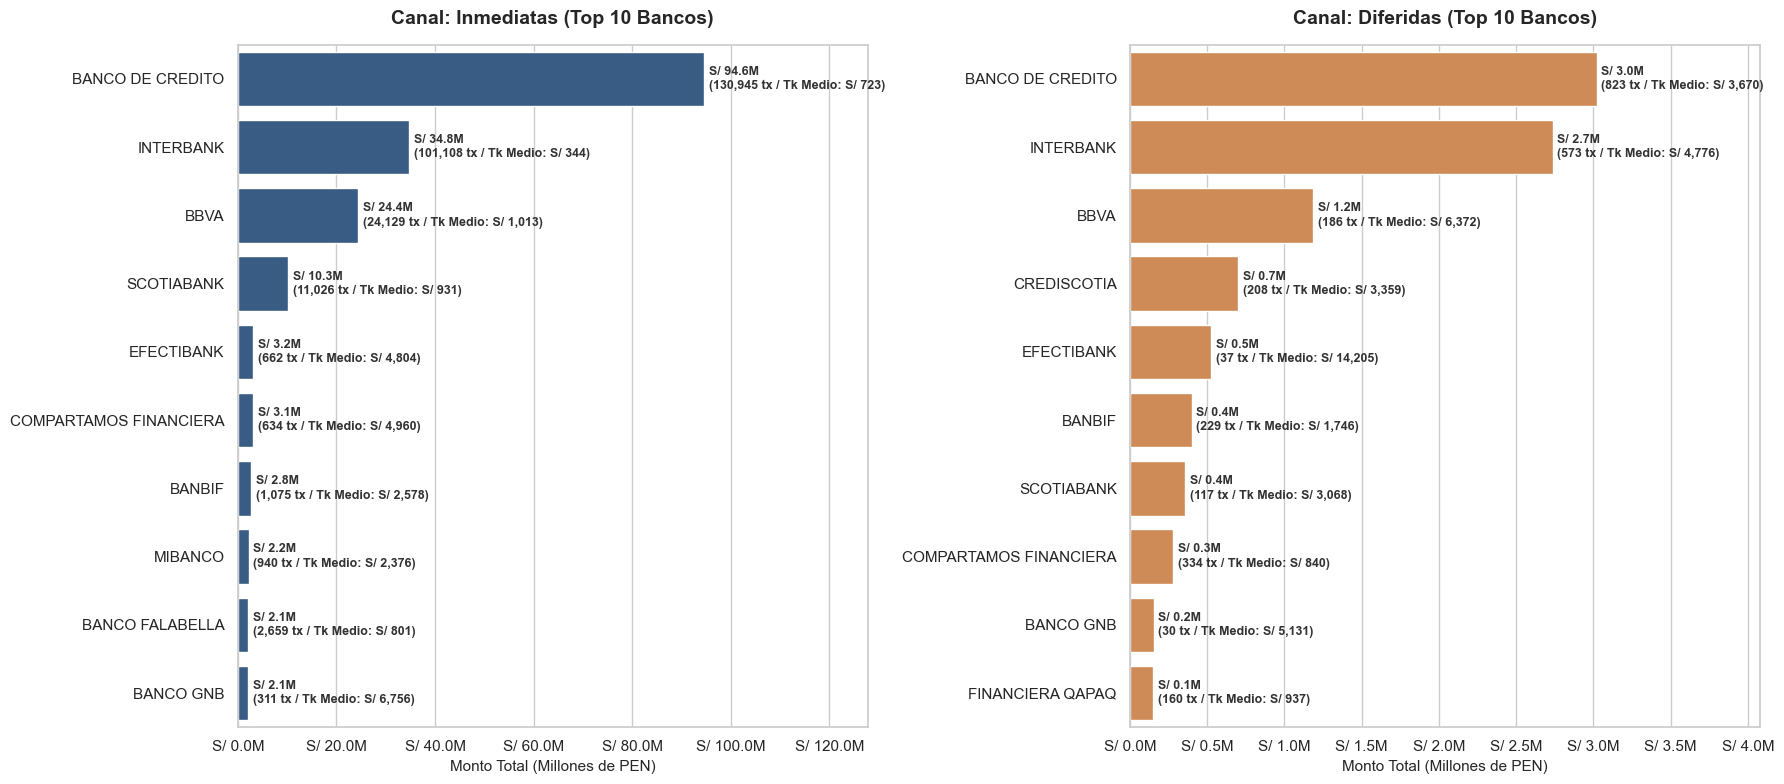

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar datos por Entidad y Tipo calculando Suma, Conteo (Operaciones) y Media (Ticket Promedio)
df_entidades = df_otros.groupby(['NOMBRE ENTIDAD DESTINO', 'Tipo']).agg(
    Monto_Total=('IMPORTE TRANSFERENCIA', 'sum'),
    Operaciones=('IMPORTE TRANSFERENCIA', 'count'),
    Ticket_Medio=('IMPORTE TRANSFERENCIA', 'mean')
).reset_index()

df_entidades['MONTO_MILLONES'] = df_entidades['Monto_Total'] / 1_000_000

# 2. Filtrar el Top 10 de entidades para cada canal de manera independiente
top_inmediatas = df_entidades[df_entidades['Tipo'] == 'Inmediatas'].nlargest(10, 'Monto_Total')
top_diferidas = df_entidades[df_entidades['Tipo'] == 'Diferidas'].nlargest(10, 'Monto_Total')

# 3. Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Crear la figura manualmente con subplots para controlar dinámicamente las etiquetas de texto
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# --- PANEL 1: INMEDIATAS ---
sns.barplot(
    data=top_inmediatas, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES',
    ax=ax1, color='#2b5c8f'
)
ax1.set_title("Canal: Inmediatas (Top 10 Bancos)", fontsize=14, weight='bold', pad=15)
ax1.set_xlabel("Monto Total (Millones de PEN)", fontsize=11)
ax1.set_ylabel("")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))

# Inyectar métricas en las barras de Inmediatas
for i, (idx, fila) in enumerate(top_inmediatas.iterrows()):
    texto_metrica = f"S/ {fila['MONTO_MILLONES']:.1f}M\n({int(fila['Operaciones']):,} tx / Tk Medio: S/ {fila['Ticket_Medio']:,.0f})"
    ax1.text(
        fila['MONTO_MILLONES'] + (top_inmediatas['MONTO_MILLONES'].max() * 0.01), 
        i, texto_metrica, 
        va='center', fontsize=9, weight='semibold', color='#333333'
    )

# --- PANEL 2: DIFERIDAS ---
sns.barplot(
    data=top_diferidas, y='NOMBRE ENTIDAD DESTINO', x='MONTO_MILLONES',
    ax=ax2, color='#e28743'
)
ax2.set_title("Canal: Diferidas (Top 10 Bancos)", fontsize=14, weight='bold', pad=15)
ax2.set_xlabel("Monto Total (Millones de PEN)", fontsize=11)
ax2.set_ylabel("")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"S/ {x:,.1f}M"))

# Inyectar métricas en las barras de Diferidas
for i, (idx, fila) in enumerate(top_diferidas.iterrows()):
    texto_metrica = f"S/ {fila['MONTO_MILLONES']:.1f}M\n({int(fila['Operaciones']):,} tx / Tk Medio: S/ {fila['Ticket_Medio']:,.0f})"
    ax2.text(
        fila['MONTO_MILLONES'] + (top_diferidas['MONTO_MILLONES'].max() * 0.01), 
        i, texto_metrica, 
        va='center', fontsize=9, weight='semibold', color='#333333'
    )

# 4. Ajustes finales de márgenes para que no se corten los textos extensos
# Damos holgura extra en los ejes X para que los textos de las etiquetas queden holgados
ax1.set_xlim(0, top_inmediatas['MONTO_MILLONES'].max() * 1.35)
ax2.set_xlim(0, top_diferidas['MONTO_MILLONES'].max() * 1.35)

plt.tight_layout()
plt.show()


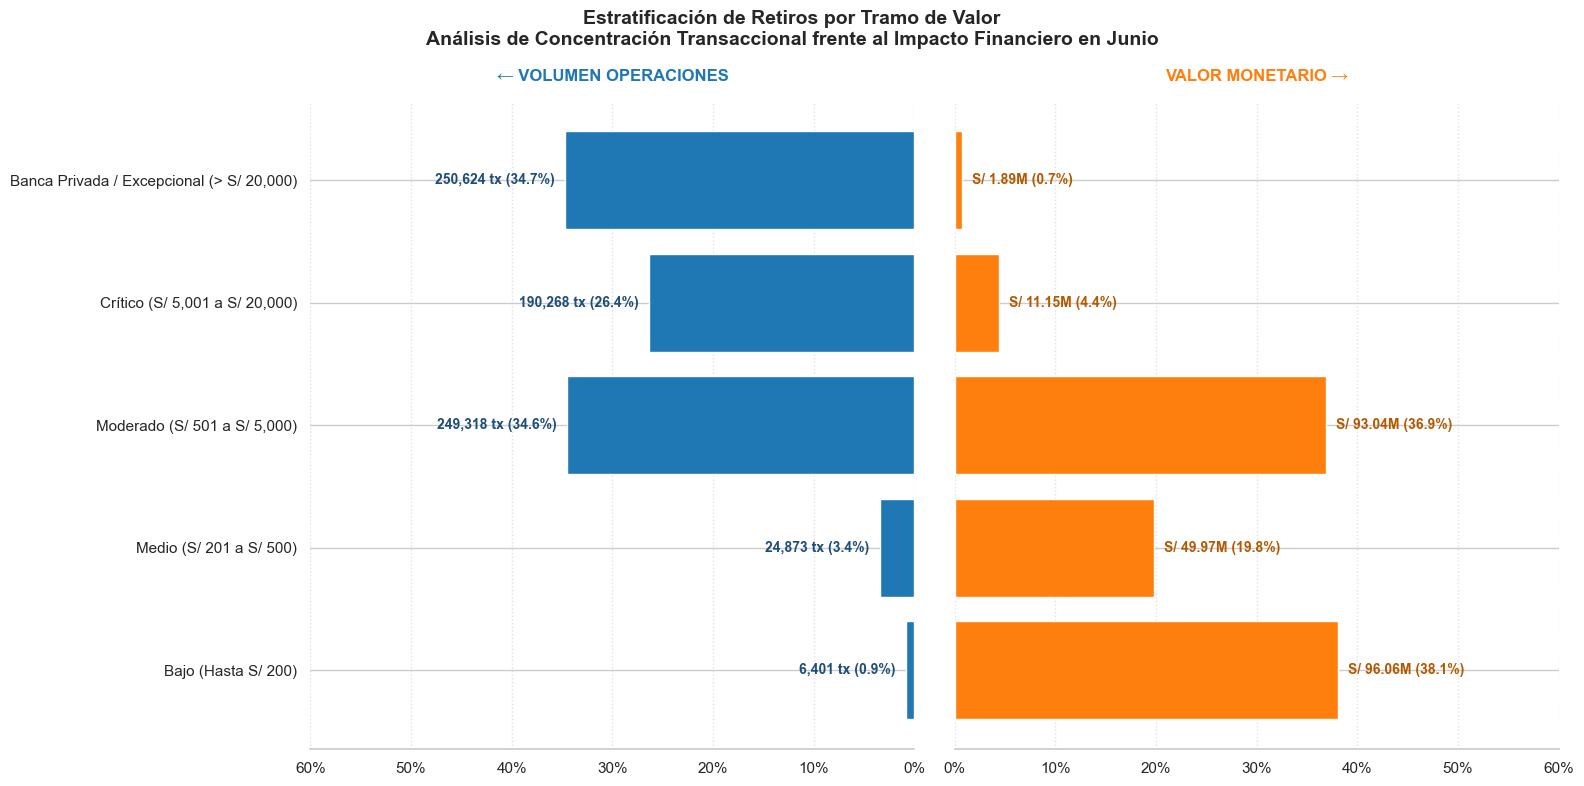

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# 1. PREPARACIÓN DE DATOS (REPLICA LOS DATOS DE TU ANÁLISIS)
# =====================================================================
# Definimos las etiquetas de los 5 tramos (en orden inverso para que el más alto salga arriba)
categorias = [
    'Banca Privada / Excepcional (> S/ 20,000)',
    'Crítico (S/ 5,001 a S/ 20,000)',
    'Moderado (S/ 501 a S/ 5,000)',
    'Medio (S/ 201 a S/ 500)',
    'Bajo (Hasta S/ 200)'
][::-1] # Invertimos el orden para el eje Y

# --- REEMPLAZA ESTOS VALORES CON LOS QUE TE SALIERON EN LA CONSOLA ---
# Ejemplo de transacciones por tramo
tx_valores = [250624, 190268, 249318, 24873, 6401][::-1] 
# Ejemplo de montos en millones por tramo
monto_valores = [1.89, 11.15, 93.04, 49.97, 96.06][::-1] 

# Calcular los totales para sacar los porcentajes del eje X
total_tx_global = sum(tx_valores)
total_monto_global = sum(monto_valores)

# Convertir los valores a porcentajes para la longitud de las barras
pct_tx = [(tx / total_tx_global) * 100 for tx in tx_valores]
pct_monto = [(monto / total_monto_global) * 100 for monto in monto_valores]

# =====================================================================
# 2. CONSTRUCCIÓN DEL GRÁFICO DE TORNADO (ESPEJO)
# =====================================================================
fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(16, 8))
plt.subplots_adjust(wspace=0) # Une ambos gráficos en el centro (eje 0)

# Colores institucionales de la imagen
color_azul = '#1f77b4'
color_naranja = '#ff7f0e'

# --- PANEL IZQUIERDO: VOLUMEN DE OPERACIONES (Barras hacia la izquierda) ---
axes[0].barh(categorias, pct_tx, color=color_azul, align='center')
axes[0].set_title('← VOLUMEN OPERACIONES', fontsize=12, weight='bold', color=color_azul, pad=15)
axes[0].set_xlim(60, 0) # Invierte el eje X para que apunte a la izquierda (máximo 60%)

# --- PANEL DERECHO: VALOR MONETARIO (Barras hacia la derecha) ---
axes[1].barh(categorias, pct_monto, color=color_naranja, align='center')
axes[1].set_title('VALOR MONETARIO →', fontsize=12, weight='bold', color=color_naranja, pad=15)
axes[1].set_xlim(0, 60) # Eje X estándar (máximo 60%)

# =====================================================================
# 3. AGREGAR ETIQUETAS DE TEXTO DETALLADAS (MÉTRICA + PORCENTAJE)
# =====================================================================
# Formatear ejes X con el símbolo de porcentaje
for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))
    ax.grid(axis='x', linestyle=':', alpha=0.6)

# Etiquetas en las barras azules (Izquierda)
for i, (pct, tx) in enumerate(zip(pct_tx, tx_valores)):
    texto = f"{tx:,} tx ({pct:.1f}%)"
    axes[0].text(pct + 1, i, texto, va='center', ha='right', fontsize=10, color='#1f4e79', weight='semibold')

# Etiquetas en las barras naranjas (Derecha)
for i, (pct, monto) in enumerate(zip(pct_monto, monto_valores)):
    texto = f"S/ {monto:,.2f}M ({pct:.1f}%)"
    axes[1].text(pct + 1, i, texto, va='center', ha='left', fontsize=10, color='#b35900', weight='semibold')

# =====================================================================
# 4. TÍTULOS Y AJUSTES FINALES
# =====================================================================
plt.suptitle(
    'Estratificación de Retiros por Tramo de Valor\n'
    'Análisis de Concentración Transaccional frente al Impacto Financiero en Junio',
    fontsize=14, weight='bold', y=0.98
)

# Limpiar bordes innecesarios para un estilo plano y moderno
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


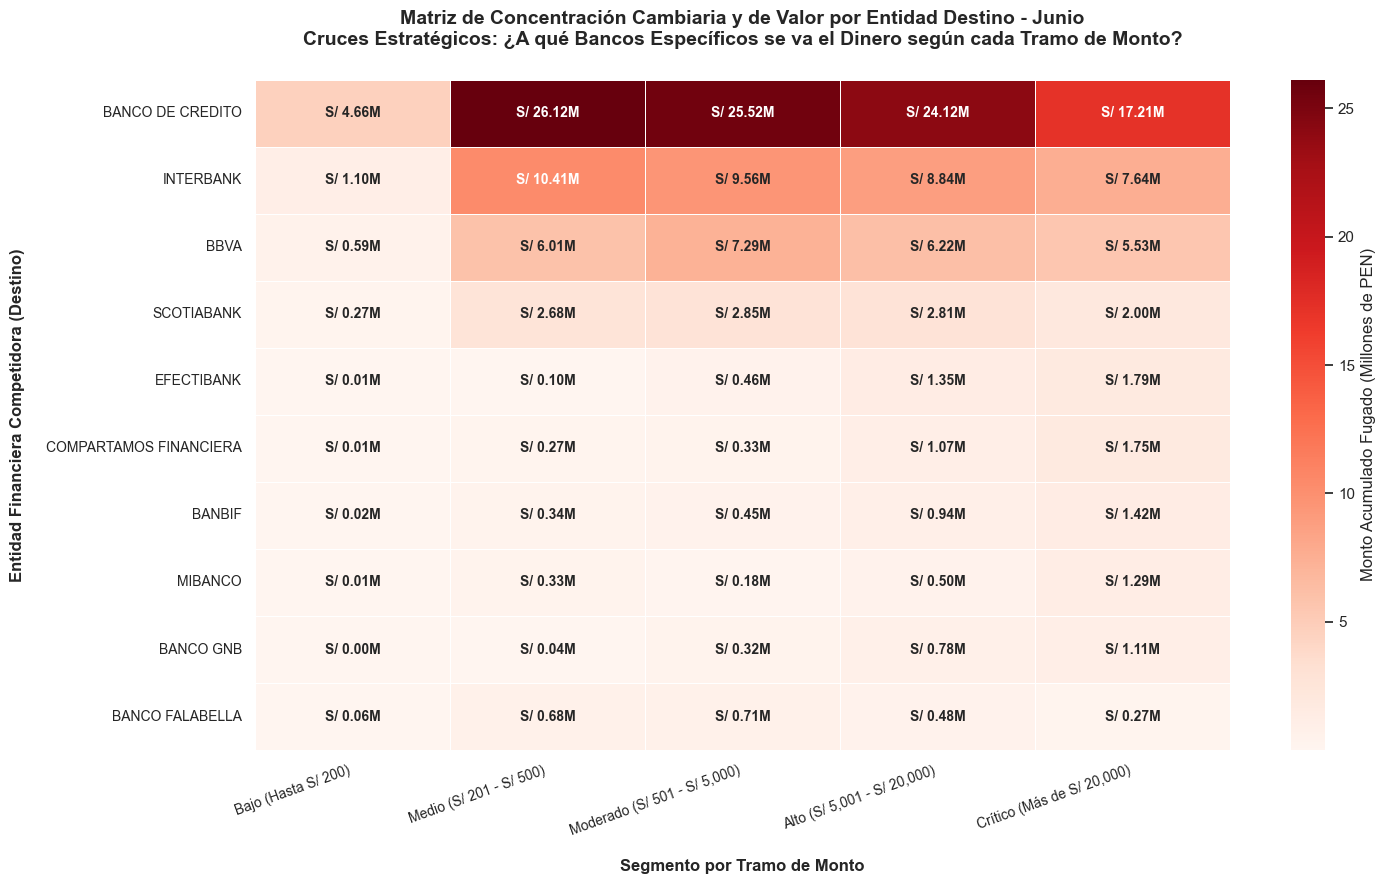

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CONSOLIDACIÓN DE TUS 5 RANGOS OFICIALES
# =====================================================================
# Límites numéricos exactos para tus tramos definidos
limites = [-np.inf, 200, 500, 5000, 20000, np.inf]

# Tu orden lógico oficial (X)
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Aseguramos la columna exacta en df_otros con tus etiquetas oficiales
df_otros['RANGO_MONTO_OFICIAL'] = pd.cut(
    df_otros['IMPORTE TRANSFERENCIA'], 
    bins=limites, 
    labels=orden_tramos
)

# =====================================================================
# 2. SELECCIÓN DEL TOP 10 DE ENTIDADES DESTINO (ORDEN DE MAYOR A MENOR)
# =====================================================================
top_entidades = (
    df_otros.groupby('NOMBRE ENTIDAD DESTINO')['IMPORTE TRANSFERENCIA']
    .sum()
    .nlargest(10)
    .index
)

# Filtrar el DataFrame para quedarnos únicamente con los 10 bancos principales
df_filtrado_mapa = df_otros[df_otros['NOMBRE ENTIDAD DESTINO'].isin(top_entidades)]

# =====================================================================
# 3. CREACIÓN DE LA MATRIZ DE MILLONES (TABLA PIVOTE)
# =====================================================================
matriz_montos = df_filtrado_mapa.pivot_table(
    index='NOMBRE ENTIDAD DESTINO',
    columns='RANGO_MONTO_OFICIAL',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='sum',
    fill_value=0
)

# Reorganizar filas de mayor a menor total y columnas usando tu orden estricto
matriz_montos = matriz_montos.reindex(index=top_entidades, columns=orden_tramos)

# Transformar los valores numéricos absolutos a formato de Millones (M)
matriz_millones = matriz_montos / 1_000_000

# =====================================================================
# 4. DISEÑO Y CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP)
# =====================================================================
plt.figure(figsize=(15, 9))
sns.set_theme(style="white")

# Usamos la paleta "Reds" para mantener los tonos rojos corporativos
ax = sns.heatmap(
    matriz_millones,
    annot=True,             # Activa los textos numéricos dentro de los bloques
    fmt=",.2f",             # Muestra dos decimales fijos para los millones
    cmap="Reds",            # Paleta de degradado de rojos de la imagen
    linewidths=0.6,         # Línea delgada blanca para separar las celdas
    cbar_kws={'label': 'Monto Acumulado Fugado (Millones de PEN)'}
)

# Modificar el texto interno de cada cuadrante para inyectar el formato monetario exacto
for text in ax.texts:
    valor_celda = float(text.get_text().replace(',', ''))
    text.set_text(f"S/ {valor_celda:,.2f}M")
    text.set_fontsize(10)
    text.set_weight('semibold')

# =====================================================================
# 5. PERSONALIZACIÓN DE TÍTULOS Y EJES CORPORATIVOS
# =====================================================================
plt.title(
    'Matriz de Concentración Cambiaria y de Valor por Entidad Destino - Junio\n'
    'Cruces Estratégicos: ¿A qué Bancos Específicos se va el Dinero según cada Tramo de Monto?',
    fontsize=14, weight='bold', pad=25
)

plt.xlabel('Segmento por Tramo de Monto', fontsize=12, labelpad=15, weight='bold')
plt.ylabel('Entidad Financiera Competidora (Destino)', fontsize=12, labelpad=15, weight='bold')

# Ajustar rotación de los textos largos en los ejes para evitar colisiones visuales
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


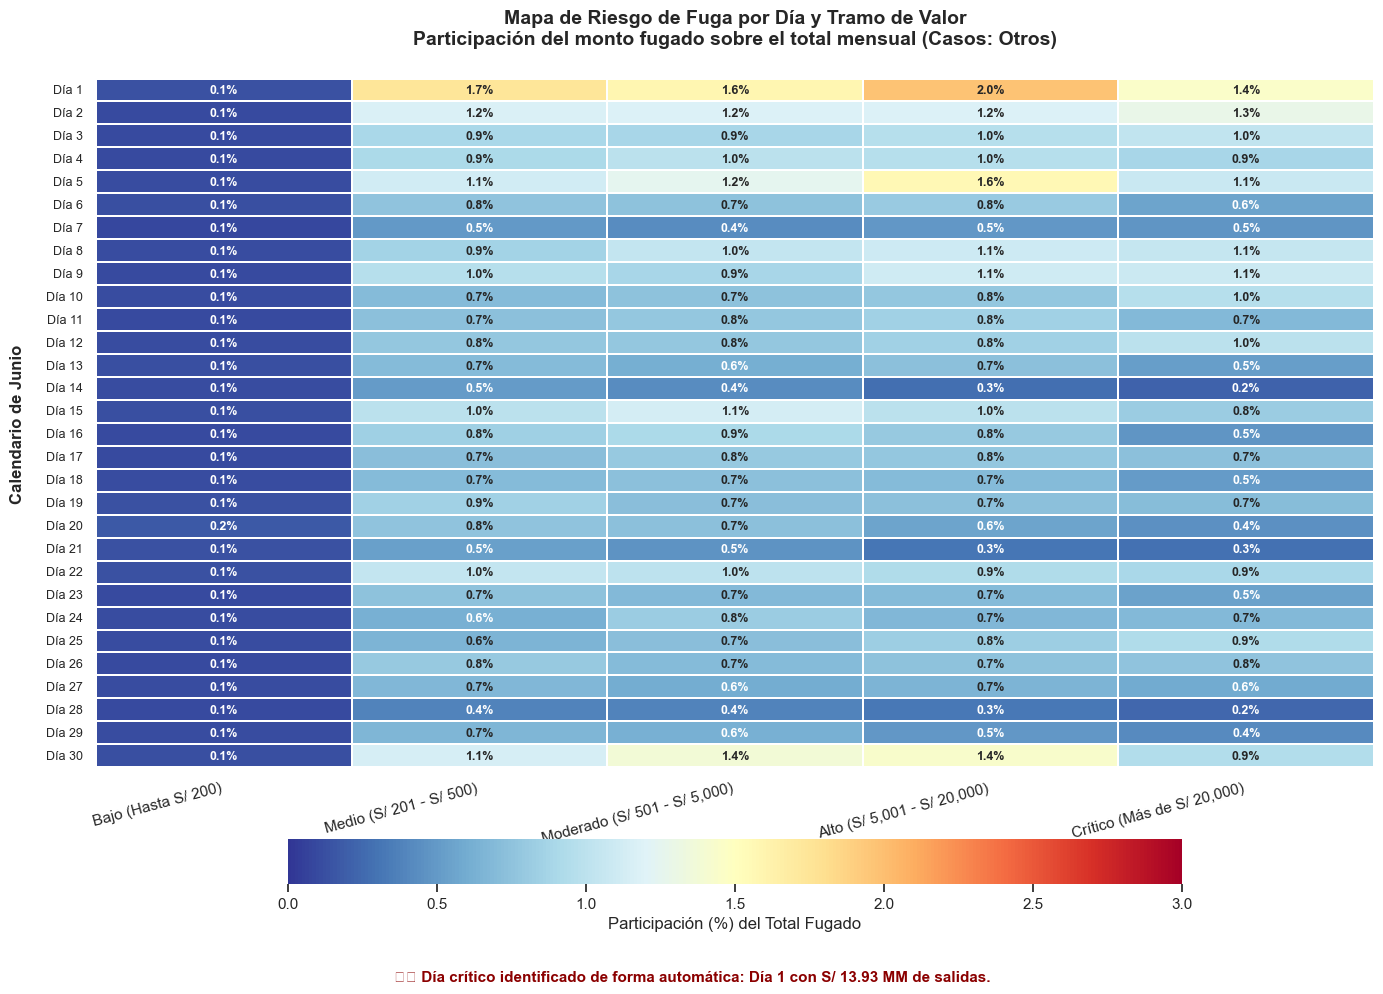

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# 🛠️ PASO CORRECTIVO EXTRA: ASEGURAR COLUMNAS EN DF_OTROS
# =====================================================================
# 1. Forzar formato correcto de fecha y crear la columna 'Día'
df_otros['FECHA TRANSFERENCIA'] = pd.to_datetime(df_otros['FECHA TRANSFERENCIA'], format='%Y%m%d')
df_otros['Día'] = df_otros['FECHA TRANSFERENCIA'].dt.day

# 2. Forzar la recreación exacta de 'RANGO_MONTO' por si se borró al filtrar
limites = [-np.inf, 200, 500, 5000, 20000, np.inf]
etiquetas = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]
df_otros['RANGO_MONTO'] = pd.cut(df_otros['IMPORTE TRANSFERENCIA'], bins=limites, labels=etiquetas)


# =====================================================================
# 1. PREPARACIÓN DE LA MATRIZ (CALENDARIO) - YA NO DARÁ ERROR
# =====================================================================
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

matriz_calendario = df_otros.pivot_table(
    index='Día',
    columns='RANGO_MONTO',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='sum',
    fill_value=0
)

# Reindexar el eje X para mantener el orden lógico de los tramos
matriz_calendario = matriz_calendario.reindex(columns=orden_tramos, fill_value=0)

# Asegurar que aparezcan los 30 días en el eje Y
matriz_calendario = matriz_calendario.reindex(range(1, 31), fill_value=0)

monto_total_global = df_otros['IMPORTE TRANSFERENCIA'].sum()
matriz_porcentajes = (matriz_calendario / monto_total_global) * 100

# =====================================================================
# 2. IDENTIFICACIÓN AUTOMÁTICA DEL DÍA CRÍTICO
# =====================================================================
fuga_diaria = df_otros.groupby('Día')['IMPORTE TRANSFERENCIA'].sum()
dia_critico = fuga_diaria.idxmax()
monto_dia_critico_m = fuga_diaria.max() / 1_000_000

# =====================================================================
# 3. CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    matriz_porcentajes,
    annot=True,              
    fmt=".1f",               
    cmap="RdYlBu_r",         
    vmin=0.0, vmax=3.0,      
    linewidths=0.2,          
    cbar_kws={
        'label': 'Participación (%) del Total Fugado', 
        'orientation': 'horizontal', 
        'pad': 0.08, 
        'shrink': 0.7
    }
)

for text in ax.texts:
    val = float(text.get_text())
    if val > 0:
        text.set_text(f"{val:.1f}%")
        text.set_fontsize(9)
        text.set_weight('semibold')
    else:
        text.set_text("") 

# =====================================================================
# 4. PERSONALIZACIÓN ESTÉTICA DEL CALENDARIO
# =====================================================================
etiquetas_y = [f"Día {i}" for i in range(1, 31)]
ax.set_yticklabels(etiquetas_y, rotation=0, fontsize=9)

plt.title(
    'Mapa de Riesgo de Fuga por Día y Tramo de Valor\n'
    'Participación del monto fugado sobre el total mensual (Casos: Otros)',
    fontsize=14, weight='bold', pad=25
)
ax.set_ylabel('Calendario de Junio', fontsize=12, labelpad=15, weight='bold')
ax.set_xlabel('Segmento de Rango de Monto', fontsize=12, labelpad=15, weight='bold')

plt.xticks(rotation=15, ha='right')

plt.figtext(
    0.5, 0.01, 
    f"⚠️ Día crítico identificado de forma automática: Día {dia_critico} con S/ {monto_dia_critico_m:,.2f} MM de salidas.", 
    ha="center", fontsize=11, color="darkred", weight="bold"
)

plt.tight_layout()
plt.show()


El mapa de calor confirma nuestra hipótesis de concentración: el tramo Bajo de transacciones hormiga no afecta la aguja del banco. El peligro real está en el tramo Crítico y Alto, que mantiene un drenaje constante de entre 0.7% y 1.4% de participación diario durante todo el mes. Sin embargo, nuestro punto más vulnerable ocurre en el Día 1, donde sufrimos un impacto masivo de S/ 13.93 Millones concentrado en los tramos más altos. Esto nos obliga a enfocar las reglas de monitoreo y los límites transaccionales especialmente en los arranques de mes y los cierres de quincena.

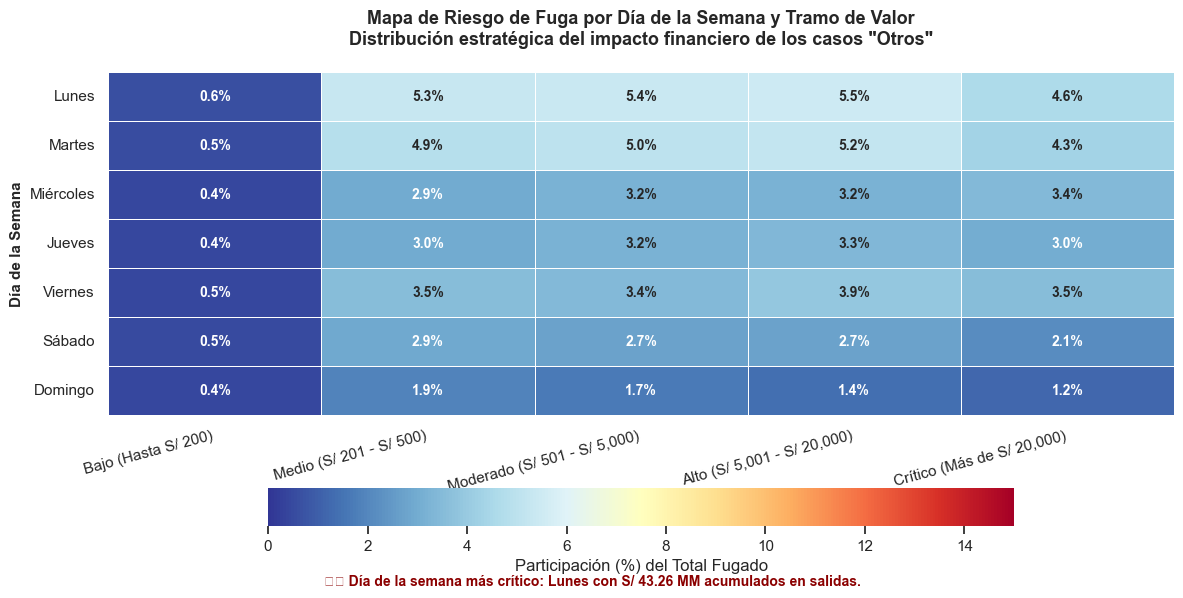

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. EXTRACCIÓN DEL DÍA DE LA SEMANA Y PREPARACIÓN DE LA MATRIZ
# =====================================================================
# Forzamos lectura correcta de fecha
df_otros['FECHA TRANSFERENCIA'] = pd.to_datetime(df_otros['FECHA TRANSFERENCIA'], dayfirst=True)

# Extraemos el nombre del día de la semana en español
df_otros['Dia_Semana'] = df_otros['FECHA TRANSFERENCIA'].dt.day_name(locale='es_ES')

# Orden lógico de las columnas (X)
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

# Orden lógico de las filas (Y) de Lunes a Domingo
orden_dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Crear la tabla pivote sumando los montos por Día de la Semana y Rango de Monto
matriz_calendario = df_otros.pivot_table(
    index='Dia_Semana',
    columns='RANGO_MONTO',
    values='IMPORTE TRANSFERENCIA',
    aggfunc='sum',
    fill_value=0
)

# Reindexar ejes X e Y para mantener la coherencia del negocio
matriz_calendario = matriz_calendario.reindex(columns=orden_tramos)
matriz_calendario = matriz_calendario.reindex(index=orden_dias_semana, fill_value=0)

# Calcular participación porcentual global
monto_total_global = df_otros['IMPORTE TRANSFERENCIA'].sum()
matriz_porcentajes = (matriz_calendario / monto_total_global) * 100

# =====================================================================
# 2. IDENTIFICACIÓN AUTOMÁTICA DEL DÍA DE LA SEMANA CRÍTICO
# =====================================================================
fuga_diaria = df_otros.groupby('Dia_Semana')['IMPORTE TRANSFERENCIA'].sum()
dia_critico = fuga_diaria.idxmax()
monto_dia_critico_m = fuga_diaria.max() / 1_000_000

# =====================================================================
# 3. CONSTRUCCIÓN DEL MAPA DE CALOR (HEATMAP MODIFICADO)
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 6)) # Un poco más compacto ya que son solo 7 filas

sns.heatmap(
    matriz_porcentajes,
    annot=True,              
    fmt=".1f",               
    cmap="RdYlBu_r",         
    vmin=0.0, vmax=15.0,     # <--- CLAVE: Ajustamos el límite máximo de escala a 15% para que los colores se distribuyan mejor entre las celdas
    linewidths=0.5,          
    cbar_kws={
        'label': 'Participación (%) del Total Fugado', 
        'orientation': 'horizontal', 
        'pad': 0.15, 
        'shrink': 0.7
    }
)

# Agregar símbolos de porcentaje
for text in ax.texts:
    val = float(text.get_text())
    if val > 0:
        text.set_text(f"{val:.1f}%")
        text.set_fontsize(10)
        text.set_weight('semibold')
    else:
        text.set_text("") 

# Personalización final de títulos
plt.title(
    'Mapa de Riesgo de Fuga por Día de la Semana y Tramo de Valor\n'
    'Distribución estratégica del impacto financiero de los casos "Otros"',
    fontsize=13, weight='bold', pad=20
)
ax.set_ylabel('Día de la Semana', fontsize=11, weight='bold')
ax.set_xlabel('Segmento de Rango de Monto', fontsize=11, weight='bold')

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

# Nota al pie dinámica
plt.figtext(
    0.5, 0.01, 
    f"⚠️ Día de la semana más crítico: {dia_critico} con S/ {monto_dia_critico_m:,.2f} MM acumulados en salidas.", 
    ha="center", fontsize=10, color="darkred", weight="bold"
)

plt.tight_layout()
plt.show()


Si cruzamos el análisis temporal, descubrimos un patrón operativo clarísimo: el vaciado de cuentas de alto valor en la categoría 'Otros' es una actividad de días hábiles. El fin de semana el riesgo se congela (cayendo a mínimos de 1.2% los domingos), pero explota de forma crítica los Lunes y Martes, acumulando solo el lunes S/ 43.26 Millones de salida. Esto confirma que el dinero grueso se mueve mediante operaciones planificadas al inicio de la jornada laboral. Mi recomendación estratégica es concentrar las reglas de fricción digital y la auditoría de operaciones diferidas pesadas en el bloque Lunes-Martes por la mañana.

In [42]:
import pandas as pd

# =====================================================================
# 1. CÁLCULO DE MÉTRICAS COMPLEJAS POR RANGO_MONTO
# =====================================================================

# Aseguramos que la columna 'Día' exista y esté bien calculada en base a tu formato
df_otros['FECHA TRANSFERENCIA'] = pd.to_datetime(df_otros['FECHA TRANSFERENCIA'], format='%Y%m%d')
df_otros['Día'] = df_otros['FECHA TRANSFERENCIA'].dt.day

# Agrupación principal para las métricas base por rango
df_resumen_rangos = df_otros.groupby('RANGO_MONTO').agg(
    Operaciones=('IMPORTE TRANSFERENCIA', 'count'),
    Clientes_Unicos=('CODIGO CLIENTE', 'nunique'),
    Ticket_Medio=('IMPORTE TRANSFERENCIA', 'mean'),
    Fuga_Total=('IMPORTE TRANSFERENCIA', 'sum')
).reset_index()


# =====================================================================
# 2. FUNCIÓN PARA ENCONTRAR LOS 3 DÍAS DE MAYOR FUGA POR RANGO
# =====================================================================
def obtener_top_3_dias(sub_df):
    # Sumamos la fuga diaria dentro de este rango específico
    fuga_por_dia = sub_df.groupby('Día')['IMPORTE TRANSFERENCIA'].sum()
    # Tomamos los 3 días con los montos más altos
    top_3 = fuga_por_dia.nlargest(3)
    
    # Formateamos el resultado en texto limpio para el reporte corporativo
    strings_dias = [f"Día {dia} (S/ {monto/1_000_000:.2f}M)" for dia, monto in top_3.items()]
    return " | ".join(strings_dias)

# Aplicamos la función a cada rango y lo guardamos en un diccionario
top_dias_por_rango = df_otros.groupby('RANGO_MONTO').apply(obtener_top_3_dias).to_dict()


# =====================================================================
# 3. IMPRESIÓN DEL REPORTE EJECUTIVO UNIFICADO
# =====================================================================
print("=" * 90)
print(" 📊  REPORTE ESTRATÉGICO DE CONCENTRACIÓN Y PICOS DE FUGA (CATEGORÍA: OTROS)")
print("=" * 90)

# Tu orden lógico oficial para asegurar que se imprima de menor a mayor valor
orden_tramos = [
    'Bajo (Hasta S/ 200)',
    'Medio (S/ 201 - S/ 500)',
    'Moderado (S/ 501 - S/ 5,000)',
    'Alto (S/ 5,001 - S/ 20,000)',
    'Crítico (Más de S/ 20,000)'
]

for rango in orden_tramos:
    # Extraemos la fila correspondiente al rango actual
    fila = df_resumen_rangos[df_resumen_rangos['RANGO_MONTO'] == rango]
    
    if len(fila) == 0:
        continue
        
    row = fila.iloc[0]
    monto_m = row['Fuga_Total'] / 1_000_000
    dias_pico = top_dias_por_rango.get(rango, "Sin datos")
    
    print(f" 🔥 RANGO: {rango.upper()}")
    print(f"    • Fuga Total Acumulada : S/ {row['Fuga_Total']:,.2f} PEN ({monto_m:,.2f} Millones)")
    print(f"    • Volumen de Operaciones: {int(row['Operaciones']):,} transacciones")
    print(f"    • Clientes Únicos      : {int(row['Clientes_Unicos']):,} usuarios")
    print(f"    • Ticket Medio Real    : S/ {row['Ticket_Medio']:,.2f} PEN")
    print(f"    • 📅 Top 3 Días Pico    : {dias_pico}")
    print("-" * 90)

print("=" * 90)


 📊  REPORTE ESTRATÉGICO DE CONCENTRACIÓN Y PICOS DE FUGA (CATEGORÍA: OTROS)
 🔥 RANGO: BAJO (HASTA S/ 200)
    • Fuga Total Acumulada : S/ 6,888,236.15 PEN (6.89 Millones)
    • Volumen de Operaciones: 146,114 transacciones
    • Clientes Únicos      : 18,041 usuarios
    • Ticket Medio Real    : S/ 47.14 PEN
    • 📅 Top 3 Días Pico    : Día 20 (S/ 0.33M) | Día 1 (S/ 0.28M) | Día 21 (S/ 0.27M)
------------------------------------------------------------------------------------------
 🔥 RANGO: MEDIO (S/ 201 - S/ 500)
    • Fuga Total Acumulada : S/ 49,388,129.95 PEN (49.39 Millones)
    • Volumen de Operaciones: 107,375 transacciones
    • Clientes Únicos      : 18,882 usuarios
    • Ticket Medio Real    : S/ 459.96 PEN
    • 📅 Top 3 Días Pico    : Día 1 (S/ 3.51M) | Día 2 (S/ 2.37M) | Día 30 (S/ 2.31M)
------------------------------------------------------------------------------------------
 🔥 RANGO: MODERADO (S/ 501 - S/ 5,000)
    • Fuga Total Acumulada : S/ 49,972,344.92 PEN (49.97 